<a href="https://colab.research.google.com/github/Rasel1435/MasterCourse-IT/blob/main/week_7/Inside_Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A dataset called the [Oxford-IIIT Pet Dataset](http://www.robots.ox.ac.uk/~vgg/data/pets/) that contains 7,349 images of cats and dogs from 37 different breeds will be downloaded from the fast.ai datasets collection

In [ ]:
!pip install -Uqq fastai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.3/235.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 117.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from fastai.vision.all import *

In [ ]:
path = untar_data(URLs.PETS)/'images'
path

Path('/root/.fastai/data/oxford-iiit-pet/images')

In [ ]:
len(path.ls())

7393

In [ ]:
path.ls()[:5]

(#5) [Path('/root/.fastai/data/oxford-iiit-pet/images/newfoundland_168.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Egyptian_Mau_199.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/pomeranian_82.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/shiba_inu_57.jpg'),Path('/root/.fastai/data/oxford-iiit-pet/images/Bombay_118.jpg')]

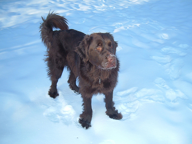

In [ ]:
img = PILImage.create(path.ls()[0])
img.to_thumb(192)

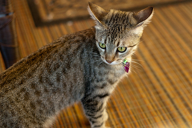

In [ ]:
img = PILImage.create(path.ls()[1])
img.to_thumb(192)

In [ ]:
def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
        path,
        get_image_files(path),
        valid_pct=0.2,
        seed=42,
        label_func=is_cat,
        item_tfms=Resize(224)
      )

In [ ]:
learn = vision_learner(dls, resnet34, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 184MB/s]


In [ ]:
learn.fine_tune(2)

epoch,train_loss,valid_loss,error_rate,time
0,0.167604,0.025645,0.007442,00:40


epoch,train_loss,valid_loss,error_rate,time
0,0.070536,0.016453,0.003383,00:40
1,0.029392,0.006399,0.002030,00:41


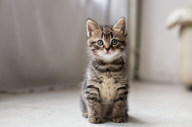

In [ ]:
img = PILImage.create("cat.jpg")
img.to_thumb(192)

In [ ]:
learn.predict(img)

('True', tensor(1), tensor([6.4995e-10, 1.0000e+00]))

In [ ]:
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: True.
Probability it's a cat: 1.000000


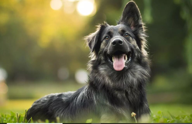

In [ ]:
img = PILImage.create("dog.JPG")
img.to_thumb(192)

In [ ]:
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

Is this a cat?: False.
Probability it's a cat: 0.000007


### Additional Resources
fastai documentation: https://docs.fast.ai/ <br/>
fastai datasets: https://docs.fast.ai/data.external.html <br/>
